In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16, ResNet50
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train,y_train),(X_test,y_test) = cifar10.load_data()

In [3]:
X_train = X_train/255
X_test = X_test/255

- **ResNet50** 또는 **VGG16(weights, include_top, input_shape)**
> - `weights`: **imagenet**으로 설정 시, imagenet data로 학습한 구조와 weights를 사용한다는 의미
> - `inlcude_top`: **False**로 설정할 경우, 특징추출부만 사용한다는 의미 (분류부는 제외)
> - `input_shape`: 입력 이미지의 shape
- **ResNet50** 또는 **VGG16.trainable**을 **False**로 지정할 경우, 해당 모델의 **weights**를 그대로 사용한다는 의미이며, **True**로 지정할 경우, 구조만 가져온 상태로 학습을 통해 **weights**를 찾겠다는 의미

In [4]:
resnet_layer = ResNet50(weights='imagenet',include_top=False,input_shape=(32,32,3))
resnet_layer.trainable = False
# ResNet50의 특징추출부만 사용
# imagenet data를 통해 학습한 weights를 그대로 로드하여 사용
# 입력 이미지의 shape은 (32,32,3)

In [5]:
cnn_model = Sequential([
    # transfer learning layer
    resnet_layer,
    # 이미지를 1d로 변경
    Flatten(),
    # -- 분류부
    BatchNormalization(),
    Dropout(0.2),
    Dense(units=512,activation='relu'),
    # class의 수가 10이므로 output layer node는 10으로 지정함
    Dense(units=10,activation='softmax')
])

In [6]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,650,122 (94.03 MB)

 Trainable params: 1,058,314 (4.04 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [7]:
cnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['acc'])

In [8]:
train_result = cnn_model.fit(X_train,y_train,validation_split=0.3,epochs=30,batch_size=1024)

Epoch 1/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 32s 494ms/step - acc: 0.2791 - loss: 2.0004 - val_acc: 0.1607 - val_loss: 3.8777
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - acc: 0.4078 - loss: 1.6750 - val_acc: 0.1527 - val_loss: 4.8754
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - acc: 0.4279 - loss: 1.6161 - val_acc: 0.1115 - val_loss: 4.5621
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - acc: 0.4388 - loss: 1.5874 - val_acc: 0.1341 - val_loss: 3.8136
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - acc: 0.4487 - loss: 1.5596 - val_acc: 0.1411 - val_loss: 3.2455
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - acc: 0.4539 - loss: 1.5471 - val_acc: 0.2024 - val_loss: 2.6240
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - acc: 0.4639 - loss: 1.5261 - val_acc: 0.2328 - val_loss: 2.2549
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - acc: 0.4701 - loss: 1.5074 - val_acc: 0.3230 - val_loss: 1.8602
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - acc: 0.46

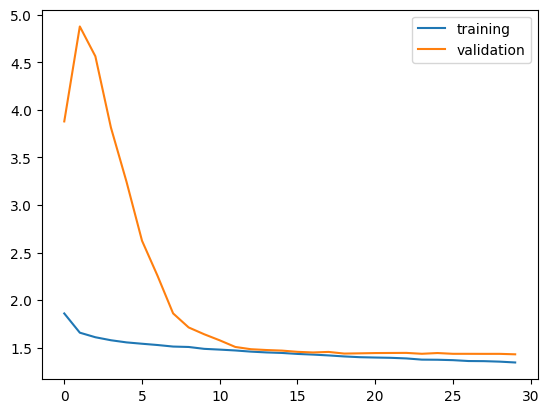

In [9]:
plt.plot(train_result.history['loss'],label='training')
plt.plot(train_result.history['val_loss'],label='validation')
plt.legend()

In [10]:
cnn_model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - acc: 0.5039 - loss: 1.4108


[1.4214550256729126, 0.5019999742507935]

In [11]:
proba = cnn_model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step


In [12]:
pred = np.argmax(proba,axis=1)

In [13]:
wrong_ind = np.argwhere(pred != y_test.reshape(pred.shape))
print(wrong_ind)

[[   0]
 [   3]
 [   4]
 ...
 [9995]
 [9996]
 [9998]]


4 [6]


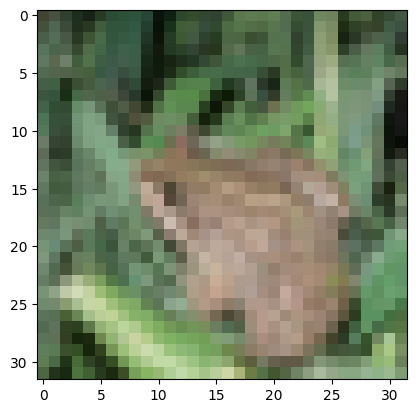

In [15]:
plt.imshow(X_test[4])
print(pred[4],y_test[4])